In [ ]:
# ==================================================================
# 假阳性去除问题：诊断 + 改进 完整 Pipeline
# 
# 本 Notebook 完成 4 件事：
#   阶段1：诊断病因 —— UMAP/t-SNE 三类对比 + 参考域标签检查
#   阶段2：建立"假阳性原型库"（FP Prototype Bank）
#   阶段3：增强匹配规则（恶性相似度 vs 假阳性相似度对比）
#   阶段4：在所有样本上对比"原方法 vs 改进方法"的去除效果
# ==================================================================

# ── 标准库 ──
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import umap

# ==================================================================
# 【配置区】—— 只需修改这里
# ==================================================================

CONFIG = {
    # ---- 项目根目录（包含 cross_cluster_matching 包）----
    "project_root": r"E:\limr\Soft\shilab-cluster-algorithm",

    # ---- 参考域路径 ----
    "reference": {
        "malignant_cells_dir": r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/malignant",
        "benign_cells_dir":    r"H:/limr/project/urine/rawdata/classification_model/UR_SingleCell/benign",
    },

    # ---- 候选域路径 ----
    "candidate": {
        "positive_folder_path": r"H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\pos",
        "negative_folder_path": r"H:\limr\project\urine\result\binary_infer\sample31\single_cell\test\neg",
    },

    # ---- 模型配置 ----
    "model": {
        "model_path": r"H:\limr\project\urine\result\classification_model\UR_SingleCell_seed300_v3\train_val_models\DenseNet161\densenet161_fold_4.pth",
        "model_type": "DenseNet161",
        "mean": [0.5918, 0.5688, 0.7202],
        "std":  [0.2469, 0.2356, 0.1270],
    },

    # ---- 输出路径 ----
    "output": {
        "base_save_dir": r"H:\limr\project\urine\results\clustering\fp_diagnostic",
    },

    # ---- 流程参数（与你 pipeline.py 一致）----
    "params": {
        "feature_layer":     "penultimate",
        "reference_k":       10,
        "batch_size":        16,
        "num_workers":       0,
        "cell_size_weight":  1.0,
        "pca_dim":           32,
    },

    # ---- 关键参数 ----
    "malignant_ref_clusters": [8, 7, 1],   # 你之前判断的恶性参考簇

    # ---- 阶段2：FP原型库参数 ----
    "fp_bank": {
        "n_fp_clusters":     5,      # FP原型库聚成几个簇
        "min_fp_cells":      50,     # 最少需要多少个FP细胞才建库
    },

    # ---- 阶段3：改进的匹配规则参数 ----
    "improved_rule": {
        "min_malignant_sim": 0.5,    # 与恶性簇的最低相似度
        "fp_margin":         0.05,   # 恶性相似度 - FP相似度 必须 > 此值
    },
}

# ── 把项目根目录加入 Python 路径 ──
sys.path.insert(0, CONFIG["project_root"])

# ── 复用你的项目模块 ──
from cross_cluster_matching.models.models import get_model_and_transform
from cross_cluster_matching.data.data_utils import (
    collect_reference_data, collect_image_paths, 
    CellImageDataset, extract_patient_id
)
from cross_cluster_matching.models.feature_extractor import extract_features_with_cell_size
from cross_cluster_matching.visualization.visualization import (
    count_non_background_pixels, set_plot_font
)

# ── 设置 ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs(CONFIG["output"]["base_save_dir"], exist_ok=True)
print(f"🖥️  使用设备：{device}")
print(f"📁  输出目录：{CONFIG['output']['base_save_dir']}")


🖥️  使用设备：cuda
📁  输出目录：G:\04PhD\03Study\05SelfLearn\results\clustering\fp_diagnostic


In [2]:

# ==================================================================
# 通用工具函数
# ==================================================================

def extract_features_from_paths(paths, model, transform, device, params,
                                 source_labels=None, desc="提取特征"):
    """
    统一的特征提取函数，复用你的 extract_features_with_cell_size
    返回：(features, sources, paths)
    """
    if len(paths) == 0:
        return np.array([]), [], []
    if source_labels is None:
        source_labels = [0] * len(paths)
    
    # 计算细胞大小
    sizes = np.log1p([count_non_background_pixels(p) for p in 
                      tqdm(paths, desc=f"  {desc}-计算大小", leave=False)])
    
    # 构建 DataLoader
    loader = DataLoader(
        CellImageDataset(paths, transform=transform, source_labels=source_labels),
        batch_size=params["batch_size"],
        shuffle=False,
        num_workers=params["num_workers"]
    )
    
    feats, sources, paths_out = extract_features_with_cell_size(
        model, loader, device, sizes,
        params["feature_layer"], params["cell_size_weight"]
    )
    return feats, sources, paths_out


def collect_candidate_cells_from_folders(folder_list_with_status):
    """
    从候选域文件夹收集所有候选恶性细胞路径
    folder_list_with_status: [(folder_path, 'positive'/'negative'), ...]
    返回：dict {pid: {'paths': [...], 'status': 'pos'/'neg'}}
    """
    specimens = {}
    for folder, status in folder_list_with_status:
        pid = extract_patient_id(folder)
        mal_dir = os.path.join(folder, "malignant_images")
        paths = collect_image_paths(mal_dir) if os.path.exists(mal_dir) else []
        if len(paths) > 0:
            specimens[pid] = {'paths': paths, 'status': status, 'folder': folder}
    return specimens


# ==================================================================
# ███████  阶段0：加载模型 + 处理参考域  ███████
# ==================================================================

print("\n" + "="*70)
print("  阶段0：加载模型 + 处理参考域")
print("="*70)

# ── 加载模型 ──
print("\n📦 加载模型...")
model, transform, _ = get_model_and_transform(
    CONFIG["model"]["model_type"], device, CONFIG["model"]["model_path"],
    mean=CONFIG["model"]["mean"], std=CONFIG["model"]["std"]
)
model.eval()
print(f"✅ 模型加载完成：{CONFIG['model']['model_type']}")

# ── 加载参考域 ──
print("\n📂 加载参考域...")
ref_paths_raw, ref_sources_raw = collect_reference_data(
    CONFIG["reference"]["malignant_cells_dir"],
    CONFIG["reference"]["benign_cells_dir"]
)

# ⚠️ 关键检查：参考域标签是否正确
n_mal_raw = sum(1 for s in ref_sources_raw if s == 1 or s == 5)  # 兼容不同标签
n_ben_raw = sum(1 for s in ref_sources_raw if s == 0 or s == 4)
print(f"   参考域统计：")
print(f"   - 总数：{len(ref_paths_raw)}")
print(f"   - 标签分布：{pd.Series(ref_sources_raw).value_counts().to_dict()}")

if n_mal_raw == 0 and n_ben_raw == 0:
    print("   ⚠️⚠️⚠️ 警告：参考域标签全是0！这是已知Bug")
    print("   → 我将根据文件路径手动重建标签...")
    # 手动重建标签：根据路径判断
    ref_sources_raw = []
    for p in ref_paths_raw:
        if "malignant" in p.lower():
            ref_sources_raw.append(5)  # 恶性
        else:
            ref_sources_raw.append(4)  # 良性
    print(f"   ✅ 重建后标签分布：{pd.Series(ref_sources_raw).value_counts().to_dict()}")

# ── 提取参考域特征 ──
print("\n🔬 提取参考域特征...")
ref_feats, ref_sources, ref_paths = extract_features_from_paths(
    ref_paths_raw, model, transform, device, CONFIG["params"],
    source_labels=ref_sources_raw, desc="参考域"
)
print(f"✅ 参考域特征维度：{ref_feats.shape}")

# ── PCA + KMeans 聚类 ──
pca = PCA(n_components=min(CONFIG["params"]["pca_dim"], 
                            ref_feats.shape[0], ref_feats.shape[1]),
          random_state=SEED)
ref_norm = normalize(pca.fit_transform(ref_feats))

kmeans_ref = KMeans(n_clusters=CONFIG["params"]["reference_k"], 
                     random_state=SEED, n_init=10).fit(ref_norm)
ref_results = {
    'features':        ref_norm,
    'labels':          kmeans_ref.labels_,
    'source_labels':   np.array(ref_sources),
    'image_paths':     ref_paths,
    'cluster_centers': kmeans_ref.cluster_centers_,
    'n_clusters':      CONFIG["params"]["reference_k"],
    'pca':             pca
}
print(f"✅ 参考域聚类完成，K={CONFIG['params']['reference_k']}")

# ── ⚠️ 重要：验证"恶性簇"标签是否正确 ──
print("\n🔍 验证恶性簇标签...")
cluster_purity = []
for c in range(CONFIG["params"]["reference_k"]):
    mask = ref_results['labels'] == c
    cluster_sources = ref_results['source_labels'][mask]
    mal_count = np.sum((cluster_sources == 5) | (cluster_sources == 1))
    ben_count = np.sum((cluster_sources == 4) | (cluster_sources == 0))
    total = len(cluster_sources)
    mal_ratio = mal_count / total if total > 0 else 0
    cluster_purity.append({
        'cluster': c,
        'total':   total,
        'mal':     mal_count,
        'ben':     ben_count,
        'mal_ratio': mal_ratio,
        'is_in_user_malignant_list': c in CONFIG["malignant_ref_clusters"]
    })

purity_df = pd.DataFrame(cluster_purity)
print(purity_df.to_string(index=False))

# 自动推荐恶性簇（恶性比例>50%的簇）
auto_malignant = purity_df[purity_df['mal_ratio'] > 0.5]['cluster'].tolist()
print(f"\n   📌 你设置的恶性簇：{CONFIG['malignant_ref_clusters']}")
print(f"   📌 自动推荐恶性簇（恶性比例>50%）：{auto_malignant}")

if set(CONFIG['malignant_ref_clusters']) != set(auto_malignant):
    print(f"   ⚠️  警告：你的设置与自动推荐不一致！请人工核查上面的表格")
else:
    print(f"   ✅ 你的设置与自动推荐一致")

# 使用用户指定的恶性簇（也可以改用 auto_malignant）
malignant_clusters = CONFIG["malignant_ref_clusters"]
benign_clusters = [i for i in range(CONFIG["params"]["reference_k"]) 
                   if i not in malignant_clusters]
print(f"\n   恶性簇：{malignant_clusters}")
print(f"   良性簇：{benign_clusters}")

# 保存参考域诊断
purity_df.to_csv(os.path.join(CONFIG["output"]["base_save_dir"], 
                                "ref_cluster_purity.csv"), 
                 index=False, encoding='utf-8-sig')



  阶段0：加载模型 + 处理参考域

📦 加载模型...
DenseNet161模型权重加载成功！
✅ 模型加载完成：DenseNet161

📂 加载参考域...
   参考域统计：
   - 总数：1997
   - 标签分布：{4: 1318, 5: 679}

🔬 提取参考域特征...


提取特征: 100%|██████████| 125/125 [00:05<00:00, 20.91it/s]                


✅ 参考域特征维度：(1997, 2209)
✅ 参考域聚类完成，K=10

🔍 验证恶性簇标签...
 cluster  total  mal  ben  mal_ratio  is_in_user_malignant_list
       0    213    1  212   0.004695                      False
       1    270  257   13   0.951852                       True
       2    148    0  148   0.000000                      False
       3    253    0  253   0.000000                      False
       4    151    3  148   0.019868                      False
       5    179    0  179   0.000000                      False
       6    153    0  153   0.000000                      False
       7    267  263    4   0.985019                       True
       8    155  155    0   1.000000                       True
       9    208    0  208   0.000000                      False

   📌 你设置的恶性簇：[8, 7, 1]
   📌 自动推荐恶性簇（恶性比例>50%）：[1, 7, 8]
   ✅ 你的设置与自动推荐一致

   恶性簇：[8, 7, 1]
   良性簇：[0, 2, 3, 4, 5, 6, 9]



  阶段1：诊断 —— UMAP/t-SNE 三类细胞对比
  目的：确认 FP 是否在特征空间中靠近 TP（这决定后续方向）

📊 候选样本统计：
   阳性样本：6
   阴性样本：4
   总样本数：10

📂 收集三类对比数据...
   FP 候选数：337（来自阴性片子）
   TP 候选数：8893（来自阳性片子）
   TN 候选数：1318（参考域良性）

   实际采样：FP=337, TP=500, TN=500

🔬 提取三类特征...


提取特征: 100%|██████████| 32/32 [00:01<00:00, 23.91it/s]             


✅ 特征提取完成

⏳ 运行 UMAP...
⏳ 运行 t-SNE...


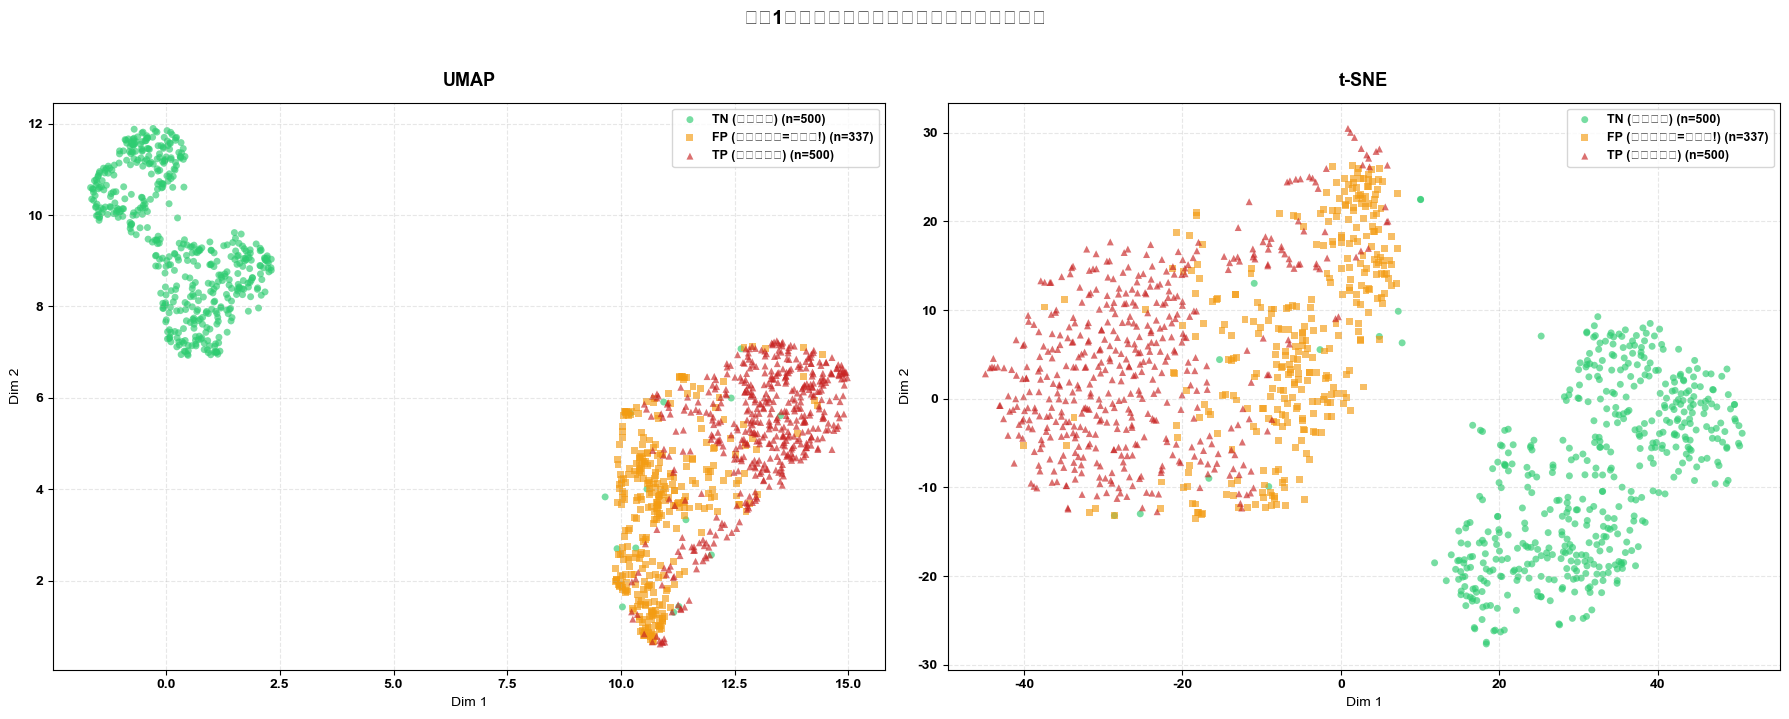


📊 三类之间的平均余弦相似度：
   TP vs FP（阳性候选 vs 阴性候选）：0.5522
   TP vs TN（阳性候选 vs 参考良性）：-0.2361
   FP vs TN（阴性候选 vs 参考良性）：-0.2159

   关键差值：(TP-FP) - (TP-TN) = +0.7883
   ⚠️  结论：FP 在特征空间中显著靠近 TP，需要 FP 原型库 + 增强匹配规则


In [4]:

# ==================================================================
# ███████  阶段1：诊断 —— UMAP/t-SNE 三类对比  ███████
# ==================================================================

print("\n" + "="*70)
print("  阶段1：诊断 —— UMAP/t-SNE 三类细胞对比")
print("  目的：确认 FP 是否在特征空间中靠近 TP（这决定后续方向）")
print("="*70)

# ── 收集候选域所有样本 ──
all_specimens_info = []
if os.path.exists(CONFIG["candidate"]["positive_folder_path"]):
    all_specimens_info.extend([
        (e.path, 'positive') 
        for e in os.scandir(CONFIG["candidate"]["positive_folder_path"]) 
        if e.is_dir()
    ])
if os.path.exists(CONFIG["candidate"]["negative_folder_path"]):
    all_specimens_info.extend([
        (e.path, 'negative') 
        for e in os.scandir(CONFIG["candidate"]["negative_folder_path"]) 
        if e.is_dir()
    ])

specimens = collect_candidate_cells_from_folders(all_specimens_info)
print(f"\n📊 候选样本统计：")
print(f"   阳性样本：{sum(1 for s in specimens.values() if s['status']=='positive')}")
print(f"   阴性样本：{sum(1 for s in specimens.values() if s['status']=='negative')}")
print(f"   总样本数：{len(specimens)}")

# ── 收集三类细胞 ──
# TP = 阳性片子的候选恶性细胞（真恶性的"代理"）
# FP = 阴性片子的候选恶性细胞（假阳性的真实样本！）
# TN = 参考域的良性细胞

print("\n📂 收集三类对比数据...")

# FP：阴性样本中所有被一阶段判为恶性的细胞 → 这就是真实的假阳性！
fp_paths_all = []
for pid, info in specimens.items():
    if info['status'] == 'negative':
        fp_paths_all.extend(info['paths'])

# TP：阳性样本中所有被一阶段判为恶性的细胞（这是"真阳性候选"，含部分假阳性）
tp_paths_all = []
for pid, info in specimens.items():
    if info['status'] == 'positive':
        tp_paths_all.extend(info['paths'])

# TN：参考域的良性细胞
tn_paths_all = [p for p, s in zip(ref_paths, ref_sources) 
                 if s == 4 or s == 0]

print(f"   FP 候选数：{len(fp_paths_all)}（来自阴性片子）")
print(f"   TP 候选数：{len(tp_paths_all)}（来自阳性片子）")
print(f"   TN 候选数：{len(tn_paths_all)}（参考域良性）")

# 各类最多采样数（避免太慢）
MAX_SAMPLE_PER_CLASS = 500
np.random.seed(SEED)

if len(fp_paths_all) > MAX_SAMPLE_PER_CLASS:
    fp_paths = list(np.random.choice(fp_paths_all, MAX_SAMPLE_PER_CLASS, replace=False))
else:
    fp_paths = fp_paths_all

if len(tp_paths_all) > MAX_SAMPLE_PER_CLASS:
    tp_paths = list(np.random.choice(tp_paths_all, MAX_SAMPLE_PER_CLASS, replace=False))
else:
    tp_paths = tp_paths_all

if len(tn_paths_all) > MAX_SAMPLE_PER_CLASS:
    tn_paths = list(np.random.choice(tn_paths_all, MAX_SAMPLE_PER_CLASS, replace=False))
else:
    tn_paths = tn_paths_all

print(f"\n   实际采样：FP={len(fp_paths)}, TP={len(tp_paths)}, TN={len(tn_paths)}")

# ── 提取三类特征 ──
print("\n🔬 提取三类特征...")
fp_feats, _, _ = extract_features_from_paths(fp_paths, model, transform, 
                                               device, CONFIG["params"], desc="FP")
tp_feats, _, _ = extract_features_from_paths(tp_paths, model, transform, 
                                               device, CONFIG["params"], desc="TP")
tn_feats, _, _ = extract_features_from_paths(tn_paths, model, transform, 
                                               device, CONFIG["params"], desc="TN")

# PCA 投影到与参考域相同的空间
fp_norm = normalize(pca.transform(fp_feats))
tp_norm = normalize(pca.transform(tp_feats))
tn_norm = normalize(pca.transform(tn_feats))

print(f"✅ 特征提取完成")

# ── 合并 + UMAP/t-SNE ──
all_feats  = np.vstack([tp_norm, fp_norm, tn_norm])
all_labels = np.array(['TP (阳性片候选)'] * len(tp_norm) +
                       ['FP (阴性片候选=假阳性!)'] * len(fp_norm) +
                       ['TN (参考良性)'] * len(tn_norm))

print(f"\n⏳ 运行 UMAP...")
umap_emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, 
                      metric='cosine', random_state=SEED).fit_transform(all_feats)

print(f"⏳ 运行 t-SNE...")
tsne_emb = TSNE(n_components=2, perplexity=min(30, len(all_feats)//4),
                 metric='cosine', random_state=SEED, init='pca',
                 n_iter=1000).fit_transform(all_feats)

# ── 可视化 ──
set_plot_font()
COLOR_MAP = {
    'TP (阳性片候选)':       '#C82423',
    'FP (阴性片候选=假阳性!)': '#F39C12',
    'TN (参考良性)':         '#2ECC71',
}
MARKER_MAP = {'TP (阳性片候选)':'^', 'FP (阴性片候选=假阳性!)':'s', 'TN (参考良性)':'o'}

def plot_emb(emb, lbls, title, ax):
    for cls in ['TN (参考良性)', 'FP (阴性片候选=假阳性!)', 'TP (阳性片候选)']:
        m = lbls == cls
        if m.sum() == 0: continue
        ax.scatter(emb[m,0], emb[m,1], c=COLOR_MAP[cls],
                   marker=MARKER_MAP[cls], s=25, alpha=0.65,
                   label=f"{cls} (n={m.sum()})", edgecolors='none')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("阶段1：三类细胞特征空间分布（核心诊断图）",
             fontsize=14, fontweight='bold', y=1.02)
plot_emb(umap_emb, all_labels, "UMAP", axes[0])
plot_emb(tsne_emb, all_labels, "t-SNE", axes[1])
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output"]["base_save_dir"], 
                          "stage1_diagnostic_umap_tsne.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# ── 定量分析 ──
def mean_sim(A, B, n_sample=300):
    np.random.seed(SEED)
    if len(A) > n_sample:
        A = A[np.random.choice(len(A), n_sample, replace=False)]
    if len(B) > n_sample:
        B = B[np.random.choice(len(B), n_sample, replace=False)]
    sim = cosine_similarity(A, B)
    return sim.mean(), sim.std()

print("\n📊 三类之间的平均余弦相似度：")
s_tp_fp, _ = mean_sim(tp_norm, fp_norm)
s_tp_tn, _ = mean_sim(tp_norm, tn_norm)
s_fp_tn, _ = mean_sim(fp_norm, tn_norm)
print(f"   TP vs FP（阳性候选 vs 阴性候选）：{s_tp_fp:.4f}")
print(f"   TP vs TN（阳性候选 vs 参考良性）：{s_tp_tn:.4f}")
print(f"   FP vs TN（阴性候选 vs 参考良性）：{s_fp_tn:.4f}")

diagnostic_gap = s_tp_fp - s_tp_tn
print(f"\n   关键差值：(TP-FP) - (TP-TN) = {diagnostic_gap:+.4f}")
if diagnostic_gap > 0.1:
    stage1_conclusion = "FP 在特征空间中显著靠近 TP，需要 FP 原型库 + 增强匹配规则"
    print(f"   ⚠️  结论：{stage1_conclusion}")
elif diagnostic_gap > 0:
    stage1_conclusion = "FP 略微靠近 TP，FP 原型库可能有效"
    print(f"   ⚠️  结论：{stage1_conclusion}")
else:
    stage1_conclusion = "FP 不靠近 TP，问题可能在匹配规则"
    print(f"   ✅  结论：{stage1_conclusion}")



  阶段2：建立 FP 原型库
  原理：阴性片子里被一阶段判恶性的细胞 = 真实的假阳性样本
        把它们聚类，作为'假阳性原型'，与恶性原型并列对比

📦 用全部 337 个 FP 细胞建立原型库...


提取特征: 100%|██████████| 22/22 [00:01<00:00, 16.94it/s]               


✅ FP 原型库建立完成，5 个 FP 原型簇

🔍 FP 原型 vs 参考簇相似度分析：
     R0(B)  R1(M)  R2(B)  R3(B)  R4(B)  R5(B)  R6(B)  R7(M)  R8(M)  R9(B)
FP0 -0.248  0.784 -0.680 -0.736  0.016 -0.721 -0.646  0.891  0.843 -0.118
FP1 -0.363  0.674 -0.648 -0.552  0.177 -0.541 -0.484  0.702  0.785 -0.143
FP2 -0.380  0.671 -0.698 -0.479  0.342 -0.366 -0.390  0.587  0.641 -0.227
FP3 -0.180  0.698 -0.673 -0.705  0.002 -0.639 -0.515  0.772  0.751 -0.019
FP4 -0.329  0.621 -0.681 -0.418  0.381 -0.215 -0.428  0.478  0.579 -0.268


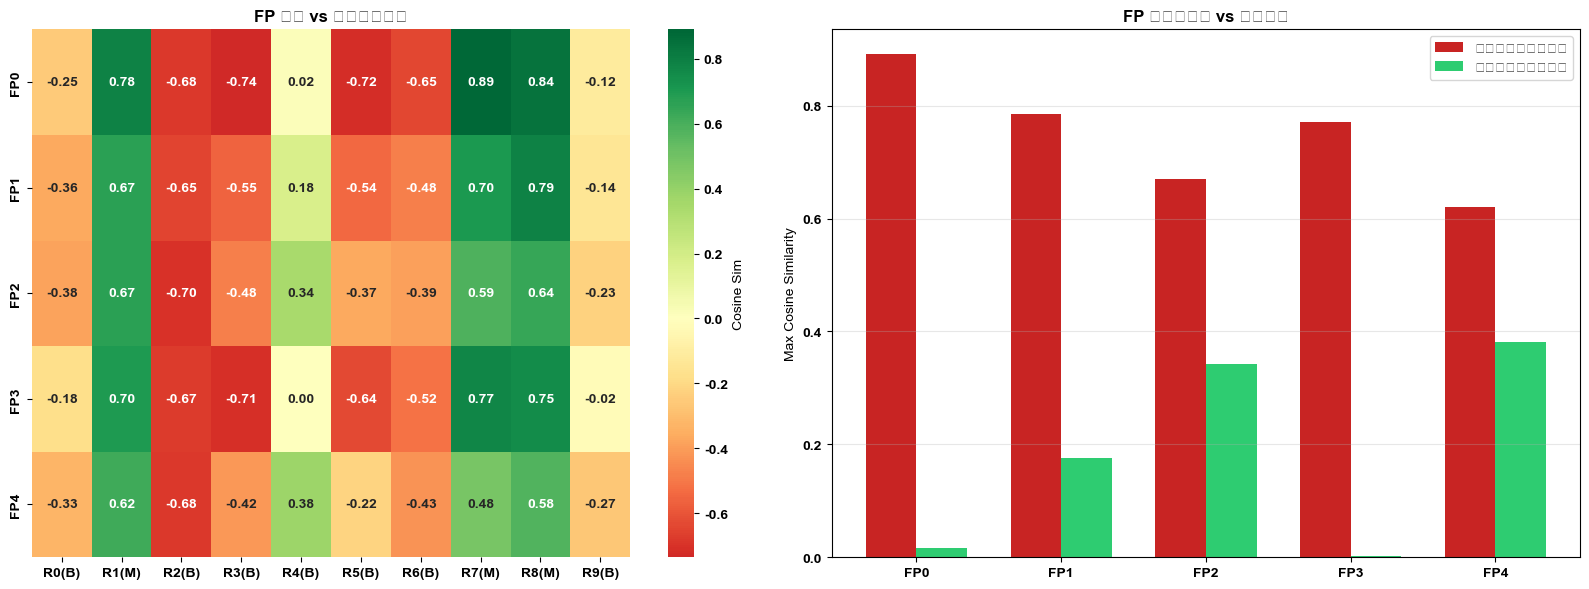


📌 关键观察：
   FP0: 与恶性簇相似度=0.891 → 这就是难以区分的'伪恶性'细胞群
   FP1: 与恶性簇相似度=0.785 → 这就是难以区分的'伪恶性'细胞群
   FP2: 与恶性簇相似度=0.671 → 这就是难以区分的'伪恶性'细胞群
   FP3: 与恶性簇相似度=0.772 → 这就是难以区分的'伪恶性'细胞群
   FP4: 与恶性簇相似度=0.621 → 这就是难以区分的'伪恶性'细胞群


In [5]:

# ==================================================================
# ███████  阶段2：建立"假阳性原型库" (FP Prototype Bank)  ███████
# ==================================================================

print("\n" + "="*70)
print("  阶段2：建立 FP 原型库")
print("  原理：阴性片子里被一阶段判恶性的细胞 = 真实的假阳性样本")
print("        把它们聚类，作为'假阳性原型'，与恶性原型并列对比")
print("="*70)

if len(fp_norm) < CONFIG["fp_bank"]["min_fp_cells"]:
    print(f"\n⚠️  FP 候选数（{len(fp_norm)}）少于 {CONFIG['fp_bank']['min_fp_cells']}，跳过 FP 库建立")
    fp_bank = None
else:
    # 用所有阴性片子的细胞建立 FP 原型库（不仅仅是采样的500个）
    print(f"\n📦 用全部 {len(fp_paths_all)} 个 FP 细胞建立原型库...")
    
    # 如果 FP 太多，限制一下加速
    if len(fp_paths_all) > 2000:
        np.random.seed(SEED)
        fp_paths_for_bank = list(np.random.choice(fp_paths_all, 2000, replace=False))
    else:
        fp_paths_for_bank = fp_paths_all
    
    fp_bank_feats, _, _ = extract_features_from_paths(
        fp_paths_for_bank, model, transform, device, CONFIG["params"], desc="FP库"
    )
    fp_bank_norm = normalize(pca.transform(fp_bank_feats))
    
    # 对 FP 细胞聚类
    n_fp_k = CONFIG["fp_bank"]["n_fp_clusters"]
    fp_kmeans = KMeans(n_clusters=n_fp_k, random_state=SEED, n_init=10).fit(fp_bank_norm)
    fp_bank = {
        'centers':   fp_kmeans.cluster_centers_,
        'labels':    fp_kmeans.labels_,
        'features':  fp_bank_norm,
        'paths':     fp_paths_for_bank,
        'n_clusters': n_fp_k
    }
    print(f"✅ FP 原型库建立完成，{n_fp_k} 个 FP 原型簇")
    
    # 分析每个 FP 原型与恶性参考簇的相似度
    print(f"\n🔍 FP 原型 vs 参考簇相似度分析：")
    fp_to_ref_sim = cosine_similarity(fp_bank['centers'], ref_results['cluster_centers'])
    fp_sim_df = pd.DataFrame(
        fp_to_ref_sim,
        index=[f"FP{i}" for i in range(n_fp_k)],
        columns=[f"R{i}{'(M)' if i in malignant_clusters else '(B)'}" 
                 for i in range(CONFIG["params"]["reference_k"])]
    )
    print(fp_sim_df.round(3).to_string())
    
    # 可视化 FP 原型库
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 热图1：FP原型 vs 所有参考簇
    sns.heatmap(fp_sim_df, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=axes[0], cbar_kws={'label': 'Cosine Sim'})
    axes[0].set_title("FP 原型 vs 参考簇相似度", fontsize=12, fontweight='bold')
    
    # 柱状图：每个FP原型最像哪个恶性簇
    mal_sim_per_fp = fp_to_ref_sim[:, malignant_clusters].max(axis=1)
    ben_sim_per_fp = fp_to_ref_sim[:, benign_clusters].max(axis=1) if benign_clusters else np.zeros(n_fp_k)
    x = np.arange(n_fp_k)
    width = 0.35
    axes[1].bar(x - width/2, mal_sim_per_fp, width, label='与恶性簇最大相似度', color='#C82423')
    axes[1].bar(x + width/2, ben_sim_per_fp, width, label='与良性簇最大相似度', color='#2ECC71')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"FP{i}" for i in range(n_fp_k)])
    axes[1].set_ylabel("Max Cosine Similarity")
    axes[1].set_title("FP 原型的恶性 vs 良性倾向", fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].axhline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["output"]["base_save_dir"],
                              "stage2_fp_bank_analysis.png"),
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # 关键观察
    print(f"\n📌 关键观察：")
    for i in range(n_fp_k):
        mal_max = mal_sim_per_fp[i]
        ben_max = ben_sim_per_fp[i]
        if mal_max > 0.6:
            print(f"   FP{i}: 与恶性簇相似度={mal_max:.3f} → 这就是难以区分的'伪恶性'细胞群")


In [6]:

# ==================================================================
# ███████  阶段3：增强匹配规则  ███████
# ==================================================================

print("\n" + "="*70)
print("  阶段3：定义增强匹配规则")
print("  规则：细胞被判为'真恶性'必须同时满足：")
print("        1. 与恶性簇相似度 > min_malignant_sim")
print("        2. 与恶性簇相似度 - 与FP原型最大相似度 > fp_margin")
print("="*70)

def classify_cell_original(cell_feat, ref_centers, malignant_clusters, 
                            benign_clusters, threshold_target=0.5, 
                            threshold_ratio=3):
    """
    原始规则（你 pipeline.py 的逻辑）：
    与目标恶性簇相似度 > threshold AND > 其他恶性簇 * 比例
    """
    sims = cosine_similarity(cell_feat.reshape(1, -1), ref_centers)[0]
    mal_sims = sims[malignant_clusters]
    max_mal = mal_sims.max()
    
    if max_mal < threshold_target:
        return False  # 不是恶性
    # 简化：只要与某个恶性簇相似度高就算恶性
    return True

def classify_cell_improved(cell_feat, ref_centers, fp_centers,
                            malignant_clusters, benign_clusters,
                            min_malignant_sim, fp_margin):
    """
    改进规则：
    1. 与恶性簇最大相似度 > min_malignant_sim
    2. 与恶性簇最大相似度 > 与FP原型最大相似度 + fp_margin
    """
    sims_ref = cosine_similarity(cell_feat.reshape(1, -1), ref_centers)[0]
    max_mal_sim = sims_ref[malignant_clusters].max()
    
    # 条件1：恶性相似度门槛
    if max_mal_sim < min_malignant_sim:
        return False, max_mal_sim, 0.0, "低恶性相似度"
    
    # 条件2：FP对比
    if fp_centers is not None:
        sims_fp = cosine_similarity(cell_feat.reshape(1, -1), fp_centers)[0]
        max_fp_sim = sims_fp.max()
        if (max_mal_sim - max_fp_sim) < fp_margin:
            return False, max_mal_sim, max_fp_sim, "更像FP原型"
        return True, max_mal_sim, max_fp_sim, "判为真恶性"
    else:
        return True, max_mal_sim, 0.0, "判为真恶性(无FP库)"



  阶段3：定义增强匹配规则
  规则：细胞被判为'真恶性'必须同时满足：
        1. 与恶性簇相似度 > min_malignant_sim
        2. 与恶性簇相似度 - 与FP原型最大相似度 > fp_margin



  阶段4：在所有样本上对比去除效果


处理样本: 100%|██████████| 10/10 [03:51<00:00, 23.13s/it]



📋 对比结果：
         pid   status  total  original_keep  original_remove  improved_keep  improved_remove  orig_remove_rate  imp_remove_rate
   SH_561505 negative     80             78                2              1               79          0.025000         0.987500
    SH_56808 negative      1              1                0              0                1          0.000000         1.000000
    SH_56909 negative    189            170               19              0              189          0.100529         1.000000
    SH_56913 negative     67             65                2              0               67          0.029851         1.000000
   SH_dxde_p positive     30             30                0              2               28          0.000000         0.933333
  SH_hqguo_p positive     61             61                0              2               59          0.000000         0.967213
 SH_wwjun_p1 positive   2281           2208               73            145             2136   

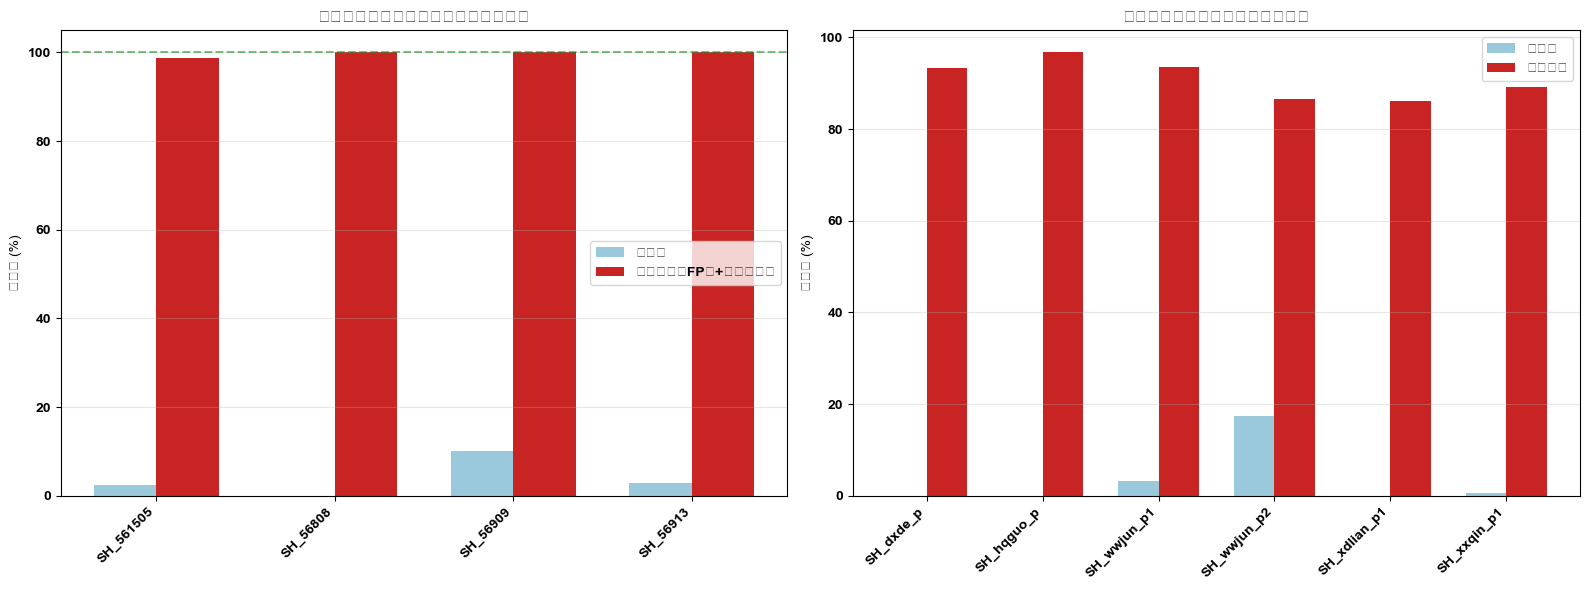


  📊 参数敏感性分析（改进方法）

  探索不同 (min_malignant_sim, fp_margin) 组合：

 min_mal_sim  fp_margin  neg_remove%  pos_remove%    优势
        0.60       0.00        97.49        76.31 21.17
        0.50       0.00        97.17        76.03 21.15
        0.55       0.00        97.17        76.12 21.06
        0.45       0.00        94.46        74.39 20.06
        0.40       0.00        93.55        73.50 20.05
        0.50       0.05        99.69        90.95  8.74
        0.55       0.05        99.69        90.98  8.71
        0.60       0.05        99.69        91.01  8.68
        0.45       0.05        96.97        89.32  7.65
        0.40       0.05        96.07        88.43  7.64
        0.50       0.10       100.00        97.00  3.00
        0.55       0.10       100.00        97.01  2.99
        0.60       0.10       100.00        97.01  2.99
        0.45       0.10        97.28        95.37  1.91
        0.40       0.10        96.38        94.48  1.90
        0.50       0.15       100.00     

In [7]:

# ==================================================================
# ███████  阶段4：在所有样本上对比 原方法 vs 改进方法  ███████
# ==================================================================

print("\n" + "="*70)
print("  阶段4：在所有样本上对比去除效果")
print("="*70)

fp_centers = fp_bank['centers'] if fp_bank else None
results = []

for pid, info in tqdm(specimens.items(), desc="处理样本"):
    paths_i = info['paths']
    status_i = info['status']
    
    # 提取特征
    feats_i, _, _ = extract_features_from_paths(
        paths_i, model, transform, device, CONFIG["params"], desc=pid
    )
    norm_i = normalize(pca.transform(feats_i))
    
    n_total = len(norm_i)
    
    # 原方法分类
    orig_keep = sum(1 for f in norm_i 
                    if classify_cell_original(
                        f, ref_results['cluster_centers'],
                        malignant_clusters, benign_clusters))
    
    # 改进方法分类
    imp_keep = 0
    details = []
    for f in norm_i:
        is_mal, mal_s, fp_s, reason = classify_cell_improved(
            f, ref_results['cluster_centers'], fp_centers,
            malignant_clusters, benign_clusters,
            CONFIG["improved_rule"]["min_malignant_sim"],
            CONFIG["improved_rule"]["fp_margin"]
        )
        if is_mal:
            imp_keep += 1
        details.append({'mal_sim': mal_s, 'fp_sim': fp_s, 
                        'kept': is_mal, 'reason': reason})
    
    results.append({
        'pid': pid,
        'status': status_i,
        'total':  n_total,
        'original_keep': orig_keep,
        'original_remove': n_total - orig_keep,
        'improved_keep':  imp_keep,
        'improved_remove': n_total - imp_keep,
        'orig_remove_rate': (n_total-orig_keep)/n_total if n_total>0 else 0,
        'imp_remove_rate':  (n_total-imp_keep)/n_total  if n_total>0 else 0,
        'details': details
    })

# ── 保存对比结果 ──
result_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'details'} for r in results
])
result_df = result_df.sort_values(['status', 'pid'])

csv_path = os.path.join(CONFIG["output"]["base_save_dir"], 
                        "stage4_comparison.csv")
result_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n📋 对比结果：")
print(result_df.to_string(index=False))
print(f"\n📁 已保存：{csv_path}")

# ── 关键指标对比 ──
print("\n" + "="*70)
print("  📊 关键指标对比")
print("="*70)

neg_results = result_df[result_df['status'] == 'negative']
pos_results = result_df[result_df['status'] == 'positive']

if len(neg_results) > 0:
    print("\n【阴性样本】期望：尽可能去除所有细胞（=假阳性）")
    orig_avg = neg_results['orig_remove_rate'].mean() * 100
    imp_avg  = neg_results['imp_remove_rate'].mean() * 100
    print(f"   原方法平均去除率：{orig_avg:.1f}%")
    print(f"   改进平均去除率：{imp_avg:.1f}%")
    print(f"   提升：{imp_avg - orig_avg:+.1f} 个百分点")

if len(pos_results) > 0:
    print("\n【阳性样本】期望：保留大部分真恶性（去除率不能太高）")
    orig_avg = pos_results['orig_remove_rate'].mean() * 100
    imp_avg  = pos_results['imp_remove_rate'].mean() * 100
    print(f"   原方法平均去除率：{orig_avg:.1f}%")
    print(f"   改进平均去除率：{imp_avg:.1f}%")
    if imp_avg - orig_avg > 30:
        print(f"   ⚠️  注意：改进方法去除率提升过多，可能误删真恶性")
    else:
        print(f"   变化：{imp_avg - orig_avg:+.1f} 个百分点")

# ── 可视化对比 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 图1：阴性样本去除率对比
if len(neg_results) > 0:
    x = np.arange(len(neg_results))
    width = 0.35
    axes[0].bar(x - width/2, neg_results['orig_remove_rate']*100, width,
                label='原方法', color='#9AC9DB')
    axes[0].bar(x + width/2, neg_results['imp_remove_rate']*100, width,
                label='改进方法（FP库+增强规则）', color='#C82423')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(neg_results['pid'], rotation=45, ha='right')
    axes[0].set_ylabel("去除率 (%)")
    axes[0].set_title("阴性样本：假阳性去除率（越高越好）",
                      fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].axhline(100, color='green', linestyle='--', alpha=0.5,
                    label='理想（100%）')

# 图2：阳性样本去除率对比
if len(pos_results) > 0:
    x = np.arange(len(pos_results))
    axes[1].bar(x - width/2, pos_results['orig_remove_rate']*100, width,
                label='原方法', color='#9AC9DB')
    axes[1].bar(x + width/2, pos_results['imp_remove_rate']*100, width,
                label='改进方法', color='#C82423')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(pos_results['pid'], rotation=45, ha='right')
    axes[1].set_ylabel("去除率 (%)")
    axes[1].set_title("阳性样本：去除率（应保持适度）",
                      fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output"]["base_save_dir"],
                          "stage4_method_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show()

# ── 参数敏感性分析（针对改进方法）──
print("\n" + "="*70)
print("  📊 参数敏感性分析（改进方法）")
print("="*70)

if fp_centers is not None and len(neg_results) > 0:
    print(f"\n  探索不同 (min_malignant_sim, fp_margin) 组合：\n")
    
    param_results = []
    for thr in [0.4, 0.45, 0.5, 0.55, 0.6]:
        for margin in [0.0, 0.05, 0.1, 0.15]:
            neg_remove_rates = []
            pos_remove_rates = []
            
            for r in results:
                details = r['details']
                # 用新参数重新判断
                keep_count = sum(1 for d in details 
                                 if d['mal_sim'] >= thr 
                                 and (d['mal_sim'] - d['fp_sim']) >= margin)
                remove_rate = (r['total'] - keep_count) / r['total']
                if r['status'] == 'negative':
                    neg_remove_rates.append(remove_rate)
                else:
                    pos_remove_rates.append(remove_rate)
            
            param_results.append({
                'min_mal_sim':  thr,
                'fp_margin':    margin,
                'neg_remove%':  np.mean(neg_remove_rates)*100 if neg_remove_rates else 0,
                'pos_remove%':  np.mean(pos_remove_rates)*100 if pos_remove_rates else 0,
            })
    
    param_df = pd.DataFrame(param_results)
    param_df['优势'] = param_df['neg_remove%'] - param_df['pos_remove%']
    param_df = param_df.sort_values('优势', ascending=False)
    print(param_df.round(2).to_string(index=False))
    print(f"\n  💡 推荐选择'优势'最大的组合：阴性去除率高 且 阳性去除率低")
    
    param_df.to_csv(os.path.join(CONFIG["output"]["base_save_dir"],
                                  "stage4_param_sensitivity.csv"),
                     index=False, encoding='utf-8-sig')


In [8]:

# ==================================================================
# ███████  最终总结  ███████
# ==================================================================

print("\n" + "="*70)
print("  🎯 最终总结")
print("="*70)
print(f"\n  阶段1诊断结论：{stage1_conclusion}")
print(f"  TP-FP 平均相似度：{s_tp_fp:.4f}")
print(f"  TP-TN 平均相似度：{s_tp_tn:.4f}")

if fp_bank:
    print(f"\n  FP 原型库：{fp_bank['n_clusters']} 个 FP 原型")

print(f"\n  📁 所有输出已保存到：{CONFIG['output']['base_save_dir']}")
print(f"     - ref_cluster_purity.csv      参考域簇纯度（核查恶性簇标签）")
print(f"     - stage1_diagnostic_umap_tsne.png  三类UMAP/t-SNE对比图")
print(f"     - stage2_fp_bank_analysis.png FP原型库分析")
print(f"     - stage4_comparison.csv       原方法vs改进方法对比")
print(f"     - stage4_method_comparison.png 对比可视化")
print(f"     - stage4_param_sensitivity.csv 参数敏感性")

print("\n  下一步建议：")
print("  1. 看 ref_cluster_purity.csv：确认你的 [8,7,1] 真的是恶性簇")
print("  2. 看 stage1 UMAP 图：确认 FP 是否混在 TP 里")
print("  3. 看 stage4 对比图：阴性样本去除率是否提升")
print("  4. 调整 CONFIG['improved_rule'] 参数找最佳组合")
print("\n" + "="*70)


  🎯 最终总结

  阶段1诊断结论：FP 在特征空间中显著靠近 TP，需要 FP 原型库 + 增强匹配规则
  TP-FP 平均相似度：0.5522
  TP-TN 平均相似度：-0.2361

  FP 原型库：5 个 FP 原型

  📁 所有输出已保存到：G:\04PhD\03Study\05SelfLearn\results\clustering\fp_diagnostic
     - ref_cluster_purity.csv      参考域簇纯度（核查恶性簇标签）
     - stage1_diagnostic_umap_tsne.png  三类UMAP/t-SNE对比图
     - stage2_fp_bank_analysis.png FP原型库分析
     - stage4_comparison.csv       原方法vs改进方法对比
     - stage4_method_comparison.png 对比可视化
     - stage4_param_sensitivity.csv 参数敏感性

  下一步建议：
  1. 看 ref_cluster_purity.csv：确认你的 [8,7,1] 真的是恶性簇
  2. 看 stage1 UMAP 图：确认 FP 是否混在 TP 里
  3. 看 stage4 对比图：阴性样本去除率是否提升
  4. 调整 CONFIG['improved_rule'] 参数找最佳组合

